# Integration - by Substitution (Change of Variables)

[Change of Variables and the Jacobian - by Serpentine Integral](https://www.youtube.com/watch?v=hhFzJvaY__U)

# Connection between derivative and integral

Let's say F(n) represents the balance in your account for transaction no n. f(n) represents the nth inflow / outflow of money. We have an initial time $n_0$ and we want to know the current balance, given all flows. We can say:

$F(n) = F(n_0) + \sum_{i=n_0}^{n_now} f(i)$

But if the inflow is continuous (think of water flowing into a bucket, constant rate over time) - let B be the volume of water in the bucket, flow rate f(t) = f (constant)

$B(t) = B(t_0) + (t - t_0)f$

If the rate varies, we break the interval from t_0 to t into n parts, we measure the flow at each period. 

We define $\Delta{t_i} = t_{i} - t_{i-1}$

$B(t) = B(t_0) + \sum_{i=1}^{n}  f(t_i) \Delta{t_i}$

As we take smaller time periods, we have f(t) representing the instantaneous rate of flow, and integrate over a limit of the interval:

$B(t) = B(t_0) + \int_{t_0}^{t}  f(t) dt$



In [7]:
# --- Step 1: Import required libraries ---
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# Ensure plots render inline inside the Jupyter Notebook
%matplotlib inline

# --- Step 2: Define the modular plotting function ---
def plot_integral(expr, var, x_lim=(-2, 2), y_lim=None, ax=None):
    """
    Integrates a SymPy expression and plots both the integrand and integral.
    
    Parameters:
    - expr: SymPy expression (the integrand)
    - var: SymPy Symbol (the variable of integration)
    - x_lim: Tuple (min, max) for the x-axis range
    - y_lim: Tuple (min, max) for the y-axis range (optional)
    - ax: Matplotlib axis object (optional, creates a new figure if None)
    """
    # 1. Compute symbolic integration
    integral_expr = sp.integrate(expr, var)
    
    # 2. Convert SymPy expressions to NumPy functions
    f_integrand = sp.lambdify(var, expr, "numpy")
    f_integral = sp.lambdify(var, integral_expr, "numpy")
    
    # 3. Generate numerical grid data
    x_vals = np.linspace(x_lim[0], x_lim[1], 400)
    y_integrand = f_integrand(x_vals)
    y_integral = f_integral(x_vals)
    
    # Handle edge cases where lambdify returns a scalar instead of an array
    if isinstance(y_integrand, (int, float)): y_integrand = np.full_like(x_vals, y_integrand)
    if isinstance(y_integral, (int, float)): y_integral = np.full_like(x_vals, y_integral)
        
    # 4. Handle plotting canvas setup
    if ax == None:
        fig, ax = plt.subplots(figsize=(6, 4))
        
    # 5. Plot curves with LaTeX labels
    ax.plot(x_vals, y_integrand, label=f"Integrand: ${sp.latex(expr)}$", color="crimson", linewidth=2)
    ax.plot(x_vals, y_integral, label=f"Integral: ${sp.latex(integral_expr)}$", color="dodgerblue", linewidth=2, linestyle="--")
    
    # 6. Apply axis configurations and limits
    ax.set_xlim(x_lim)
    if y_lim: ax.set_ylim(y_lim)
        
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.axvline(0, color="black", linewidth=0.5, linestyle=":")
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.legend(fontsize=10, loc="best")
    ax.set_xlabel(str(var))
    ax.set_ylabel("y")


# $\int x^n$, n integer, $n \ne 1$

$$\int x^n = \frac{x^{n+1}}{n+1} + c$$



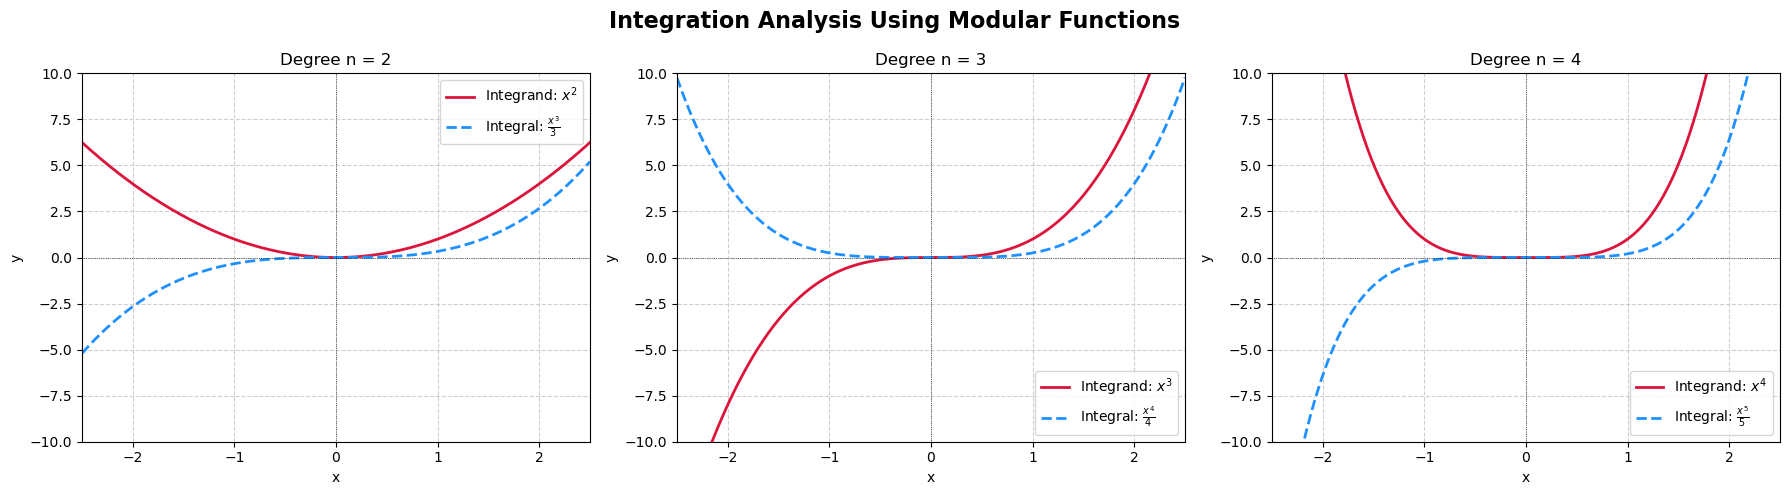

In [8]:
# --- Step 3: Execute function inside a grid for n = 2, 3, 4 ---
x = sp.Symbol('x')
n_values = [2, 3, 4]

# Set up the overall figure container
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Integration Analysis Using Modular Functions", fontsize=16, fontweight="bold")

# Loop through and pass the specific subplot axes to our function
for i, n in enumerate(n_values):
    integrand = x**n
    axes[i].set_title(f"Degree n = {n}")
    
    # Call the new function with custom graph limits
    plot_integral(expr=integrand, var=x, x_lim=(-2.5, 2.5), y_lim=(-10, 10), ax=axes[i])

plt.tight_layout()
plt.show()

# $\int \frac{1}{x}$

$$\int \frac{1}{x} = log(x) + c$$


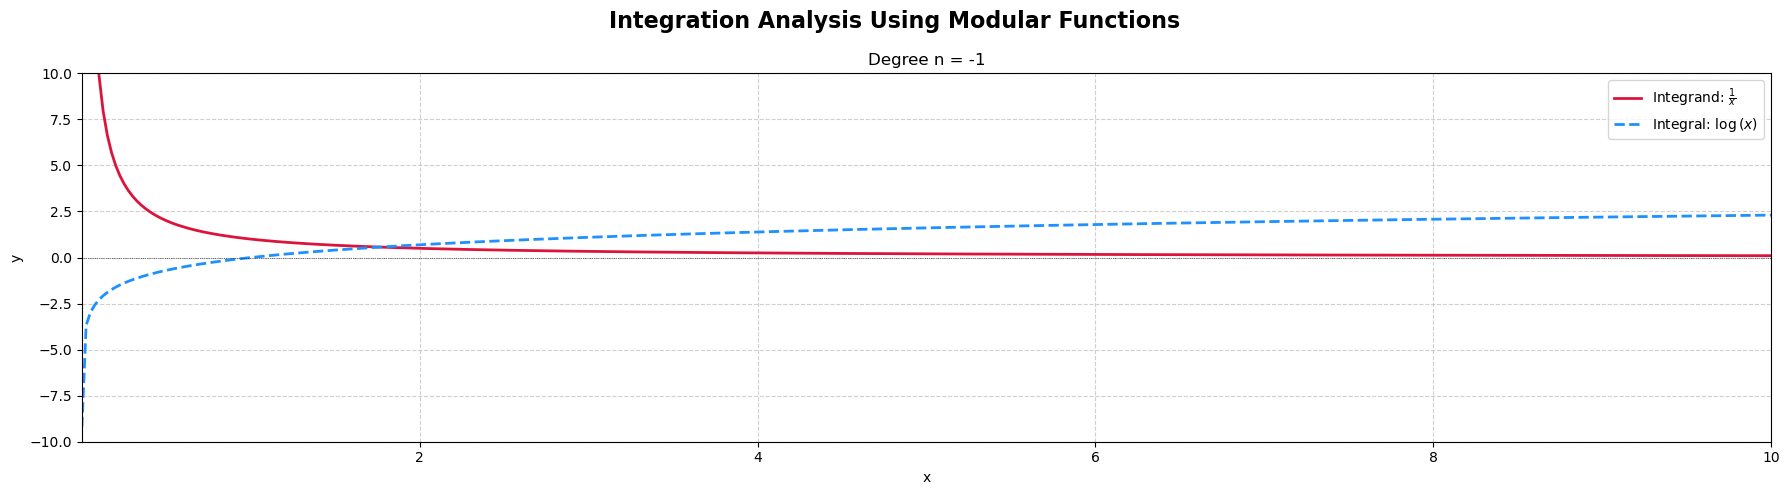

In [19]:
# --- Step 3: Execute function inside a grid for n = 2, 3, 4 ---
x = sp.Symbol('x')
n_values = [2, 3, 4]

# Set up the overall figure container
fig, axes = plt.subplots(1, 1, figsize=(18, 5))
fig.suptitle("Integration Analysis Using Modular Functions", fontsize=16, fontweight="bold")

integrand = x**-1
axes.set_title(f"Degree n = {-1}")

# Call the new function with custom graph limits
plot_integral(expr=integrand, var=x, x_lim=(0.0001, 10), y_lim=(-10, 10), ax=axes)

plt.tight_layout()
plt.show()